# Customer Retention & Churn Analysis

**Future Interns – Data Science & Analytics Internship**

### Task 2
Analyze customer churn, retention trends, and customer lifetime for a subscription-based business.

## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non

In [4]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Understanding

In [5]:
# Display data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Statistical Summary

In [7]:
# Summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Duplicate Records

In [8]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Data Cleaning

Before performing the analysis, the dataset is checked for inconsistencies such as incorrect data types, blank values, missing values, and duplicate records to ensure data quality.

In [9]:
# Check the data type of TotalCharges
print("Data Type of TotalCharges:", df["TotalCharges"].dtype)

# Count blank values
print("Blank values in TotalCharges:", (df["TotalCharges"] == " ").sum())

Data Type of TotalCharges: object
Blank values in TotalCharges: 11


## Cleaning the TotalCharges Column

The `TotalCharges` column contains blank values stored as empty strings, causing the column to be interpreted as an object instead of a numeric type. These blank values are converted to `NaN`, and the corresponding rows are removed to ensure accurate analysis.

In [10]:
# Replace blank values with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Remove rows with missing TotalCharges
df.dropna(subset=["TotalCharges"], inplace=True)

# Verify the changes
print("Data Type:", df["TotalCharges"].dtype)
print("Missing Values:", df["TotalCharges"].isnull().sum())
print("Dataset Shape:", df.shape)

Data Type: float64
Missing Values: 0
Dataset Shape: (7032, 21)


## Data Cleaning Summary

After cleaning the dataset:

- Blank values in the `TotalCharges` column were replaced with missing values (`NaN`).
- The column was converted to a numeric data type.
- Records containing missing `TotalCharges` values were removed.
- The dataset is now clean and ready for exploratory data analysis.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand customer characteristics, subscription behavior, and churn patterns through descriptive statistics and visualizations. This section provides key business metrics and insights before performing detailed churn analysis.

## Key Business Metrics

In [11]:
# Calculate key business metrics

total_customers = len(df)
churned_customers = (df["Churn"] == "Yes").sum()
retained_customers = (df["Churn"] == "No").sum()

churn_rate = (churned_customers / total_customers) * 100
retention_rate = (retained_customers / total_customers) * 100

avg_monthly_charges = df["MonthlyCharges"].mean()
avg_total_charges = df["TotalCharges"].mean()
avg_tenure = df["tenure"].mean()

print(f"Total Customers      : {total_customers}")
print(f"Churned Customers    : {churned_customers}")
print(f"Retained Customers   : {retained_customers}")
print(f"Churn Rate           : {churn_rate:.2f}%")
print(f"Retention Rate       : {retention_rate:.2f}%")
print(f"Average Monthly Fee  : ${avg_monthly_charges:.2f}")
print(f"Average Total Charges: ${avg_total_charges:.2f}")
print(f"Average Tenure       : {avg_tenure:.2f} months")

Total Customers      : 7032
Churned Customers    : 1869
Retained Customers   : 5163
Churn Rate           : 26.58%
Retention Rate       : 73.42%
Average Monthly Fee  : $64.80
Average Total Charges: $2283.30
Average Tenure       : 32.42 months


## Churn Distribution

In [12]:
# Count churned and retained customers
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


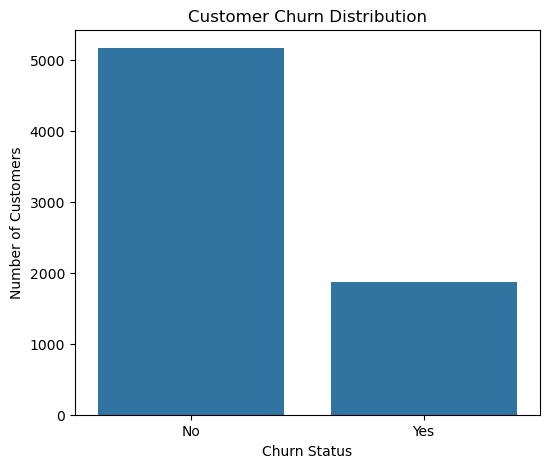

In [13]:
# Visualize customer churn distribution

plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

# Churn Analysis

This section analyzes customer churn across different customer segments to identify the key factors influencing customer retention and churn. The analysis focuses on demographics, subscription plans, payment methods, and service usage.

## Churn by Gender

This analysis compares churn rates between male and female customers to determine whether gender has a significant impact on customer retention.

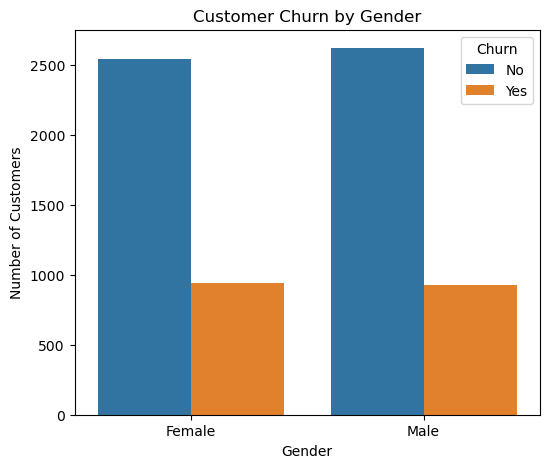

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## Churn by Contract Type

Contract type plays a significant role in customer retention. This analysis identifies which contract plans experience the highest customer churn.

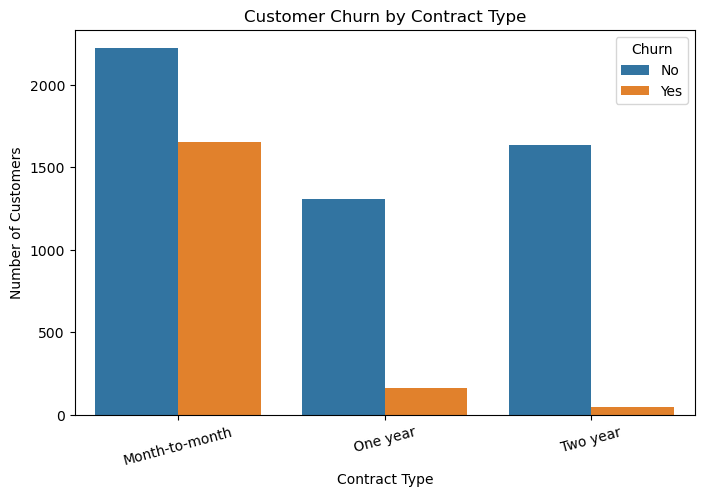

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

## Churn by Internet Service

This visualization examines whether customers using different internet service types have different churn behaviors.

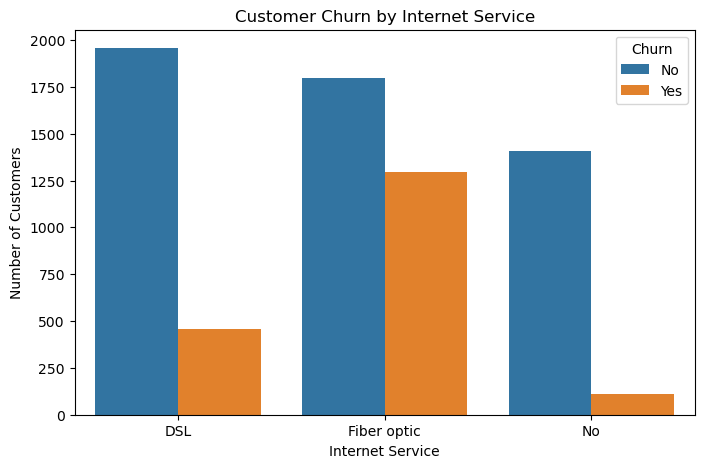

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

## Churn by Payment Method

This analysis explores whether payment methods influence customer churn and retention.

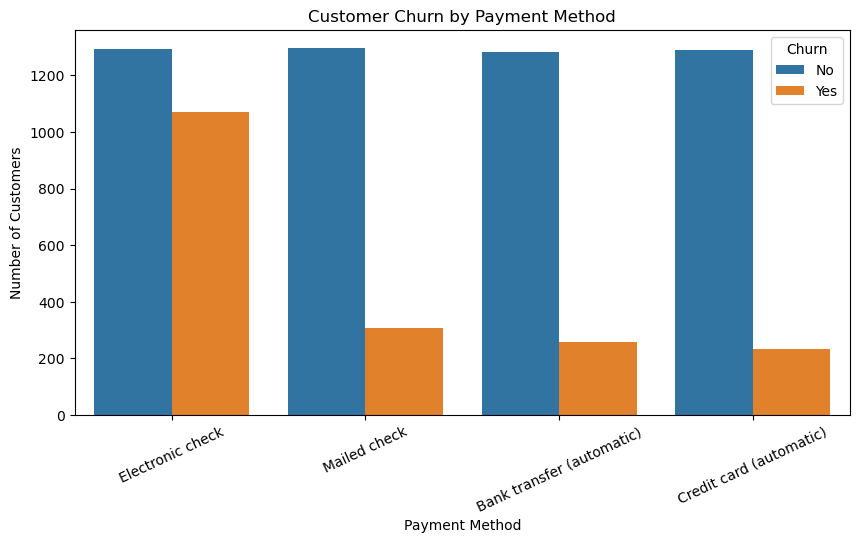

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25)

plt.show()

# Customer Lifetime Analysis

Customer lifetime is measured using the **tenure** of each customer. Analyzing tenure helps identify how long customers remain with the company and whether newer customers are more likely to churn than long-term customers.

## Customer Tenure Distribution

The following histogram illustrates how long customers stay with the company before leaving or remaining active.

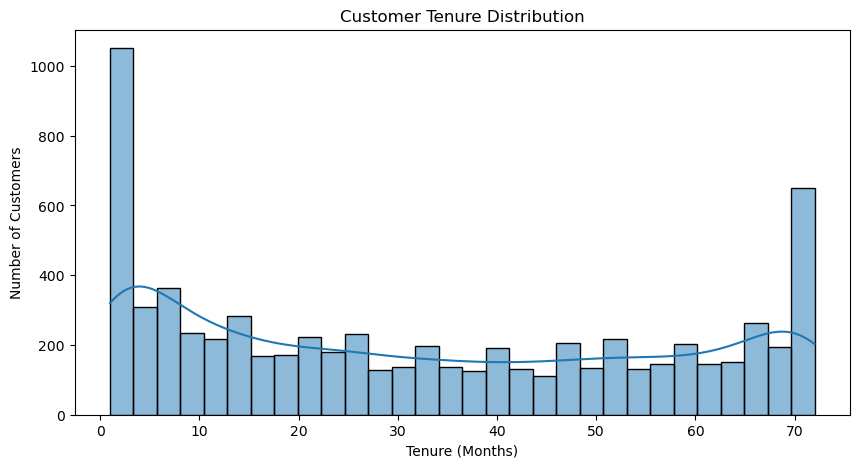

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

## Customer Churn by Tenure

This visualization compares customer tenure with churn status to identify whether customers with shorter tenures are more likely to leave.

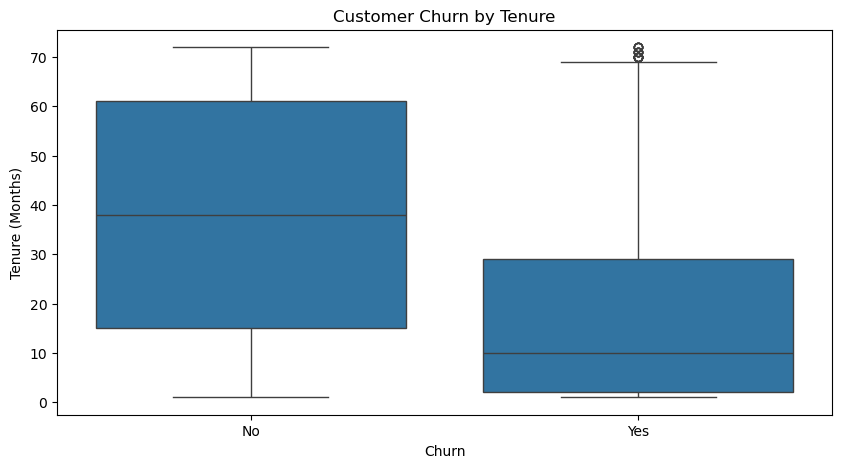

In [21]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Churn by Tenure")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## Monthly Charges by Churn Status

This analysis compares monthly subscription charges between retained and churned customers.

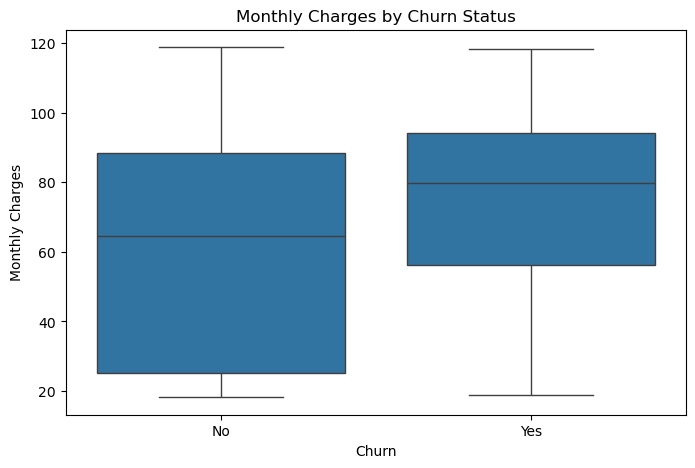

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## Total Charges by Churn Status

This visualization compares the total amount spent by customers who churned and those who remained with the company.

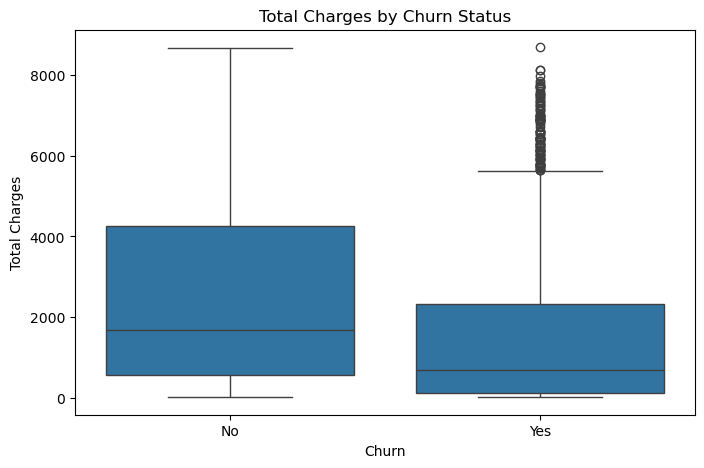

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

# Customer Cohort Analysis

Cohort analysis groups customers based on their tenure to understand retention patterns across different stages of the customer lifecycle. This helps identify which customer groups are more likely to churn.

## Customer Tenure Cohorts

In [25]:
# Create tenure cohorts

bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 Months",
    "13-24 Months",
    "25-36 Months",
    "37-48 Months",
    "49-60 Months",
    "61-72 Months"
]

df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)

In [26]:
# Calculate churn percentage by tenure cohort

cohort = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

cohort

Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-36 Months,78.365385,21.634615
37-48 Months,80.971129,19.028871
49-60 Months,85.576923,14.423077
61-72 Months,93.390192,6.609808


## Churn Percentage by Customer Cohort

The following chart shows the percentage of retained and churned customers across different tenure groups. This helps identify which customer cohorts have the highest risk of churn.

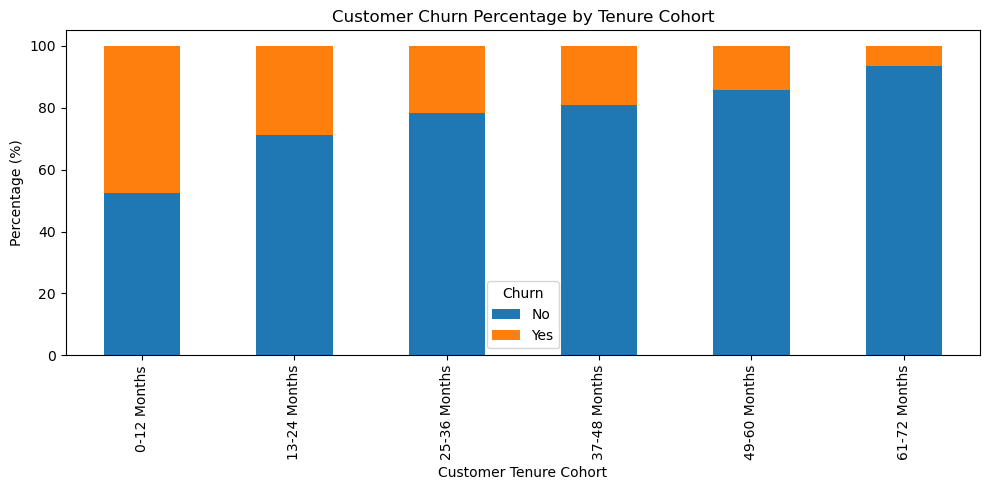

In [27]:
cohort.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Customer Churn Percentage by Tenure Cohort")
plt.xlabel("Customer Tenure Cohort")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

# Business Insights & Recommendations

## Key Findings

- The overall customer churn rate is **26.58%**, while the retention rate is **73.42%**.
- Customers with **month-to-month contracts** have the highest churn compared to one-year and two-year contracts.
- Customers with **shorter tenure (0–12 months)** are significantly more likely to churn than long-term customers.
- Higher monthly charges are associated with increased churn.
- Contract type, internet service, payment method, and customer tenure are the major factors influencing customer retention.

## Business Recommendations

- Encourage customers to switch to annual or two-year contracts through discounts or loyalty offers.
- Strengthen customer onboarding and engagement during the first 12 months to reduce early churn.
- Introduce loyalty rewards for long-term customers.
- Review pricing strategies for customers with high monthly charges.
- Improve customer support and proactively engage customers who are at high risk of churning.

# Conclusion

This project analyzed customer retention and churn patterns using the Telco Customer Churn dataset. Data cleaning, exploratory data analysis, customer lifetime analysis, and tenure-based cohort analysis revealed the key drivers of customer churn.

The findings indicate that early-stage customers, month-to-month contracts, and higher monthly charges contribute significantly to customer churn. By implementing targeted retention strategies such as long-term contract incentives, improved onboarding, and loyalty programs, businesses can improve customer retention and reduce revenue loss.

The insights generated from this analysis can support data-driven decision-making for subscription-based businesses.

In [28]:
# Export cleaned dataset for Power BI
df.to_csv("../dataset/cleaned_telco_customer_churn.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
